# ==============================================================================
# 📱 TELECOMMUNICATIONS: CHURN PROBABILITY CALIBRATION FOR DECISION TREES
# ==============================================================================
### Core Business Problem:
Standard **Decision Trees** produce uncalibrated probabilities: leaf nodes either output 0.0 or 1.0 or fractions based on very small leaf sample counts. This creates extreme step jumps that distort ROI calculations in marketing discount campaigns.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, accuracy_score, classification_report

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Telco Churn Calibration Environment initialized.")


✅ STEP 1: Telco Churn Calibration Environment initialized.


In [2]:
# STEP 2: DATA INGESTION & VALIDATION SPLIT
data_path = 'data/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv' if os.path.exists('data/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv') else 'data/customer_churn/customer_churn.csv'
df = pd.read_csv(data_path)
df.columns = [c.strip().lower() for c in df.columns]

if 'customerid' in df.columns:
    df = df.drop(columns=['customerid'])

target = 'churn'
df[target] = df[target].astype(str).str.strip().str.lower().map({'yes': 1, 'no': 0}).fillna(0).astype(int)

if 'totalcharges' in df.columns and df['totalcharges'].dtype == object:
    df['totalcharges'] = pd.to_numeric(df['totalcharges'].str.strip(), errors='coerce')

num_cols = [c for c in df.columns if c != target and df[c].dtype in [np.float64, np.int64]]
cat_cols = [c for c in df.columns if c != target and c not in num_cols]

X = df[num_cols + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Data shape: {df.shape} | Training: {X_train.shape} | Test: {X_test.shape}")
df.head()


Data shape: (7043, 20) | Training: (5634, 19) | Test: (1409, 19)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
# STEP 3: PREPROCESSING
num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])


In [4]:
# STEP 4: BASE ESTIMATOR (DECISION TREE)
raw_tree = Pipeline([
    ('prep', preprocessor),
    ('tree', DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42))
])


In [5]:
# STEP 5 & 6: TRAINING UNCALIBRATED & CALIBRATED TREE
raw_tree.fit(X_train, y_train)

calib_sigmoid = CalibratedClassifierCV(raw_tree, method='sigmoid', cv=5)
calib_sigmoid.fit(X_train, y_train)

calib_isotonic = CalibratedClassifierCV(raw_tree, method='isotonic', cv=5)
calib_isotonic.fit(X_train, y_train)

models = {
    'Uncalibrated DecisionTree': raw_tree,
    'Platt Sigmoid Calibration': calib_sigmoid,
    'Isotonic Calibration': calib_isotonic
}


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [6]:
# STEP 7: EVALUATION & BRIER SCORE
results = []
probs = {}
for name, model in models.items():
    p = model.predict_proba(X_test)[:, 1]
    probs[name] = p
    results.append({
        'Model': name,
        'Brier Score': round(brier_score_loss(y_test, p), 4),
        'Log Loss': round(log_loss(y_test, p), 4),
        'ROC AUC': round(roc_auc_score(y_test, p), 4)
    })
print(pd.DataFrame(results).to_string(index=False))


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


                    Model  Brier Score  Log Loss  ROC AUC
Uncalibrated DecisionTree       0.1415    0.4541   0.8271
Platt Sigmoid Calibration       0.1397    0.4328   0.8397
     Isotonic Calibration       0.1383    0.4226   0.8397


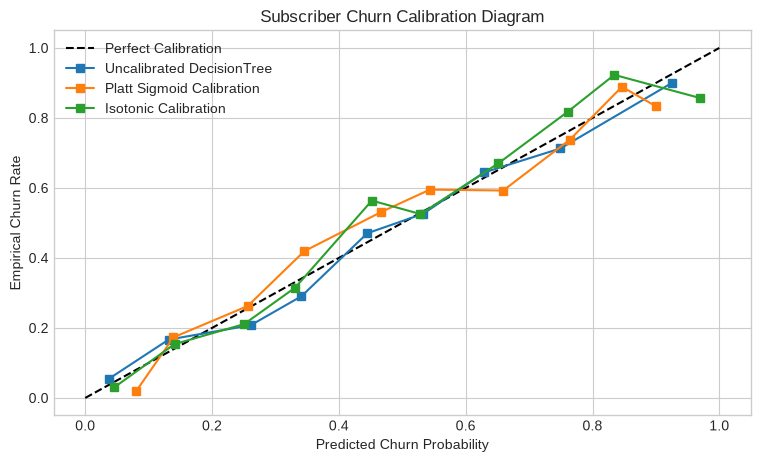

In [7]:
# STEP 8: RELIABILITY DIAGRAM
plt.figure(figsize=(9, 5))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
for name, p in probs.items():
    prob_true, prob_pred = calibration_curve(y_test, p, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='s', label=name)

plt.xlabel('Predicted Churn Probability')
plt.ylabel('Empirical Churn Rate')
plt.title('Subscriber Churn Calibration Diagram')
plt.legend()
plt.show()


In [8]:
# STEP 9: 5-FOLD CV STABILITY
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(calib_sigmoid, X, y, cv=cv5, scoring='neg_brier_score')
print(f"5-Fold CV Brier Score: {-scores.mean():.4f} +/- {scores.std():.4f}")


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

...

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

5-Fold CV Brier Score: 0.1393 +/- 0.0056


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


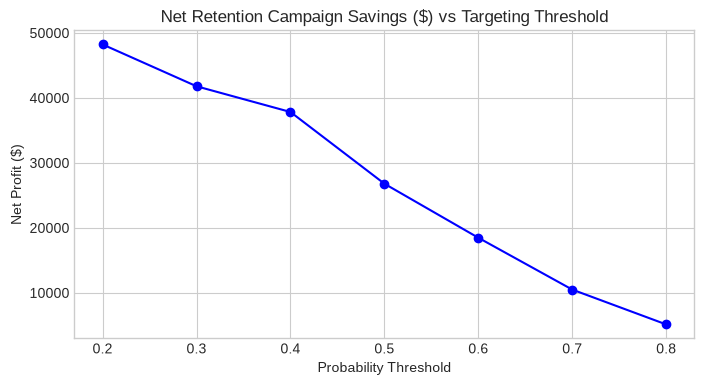

In [9]:
# STEP 10: MARKETING DISCOUNT ROI SENSITIVITY
# Smooth calibrated probabilities allow optimal thresholding for retention coupons
thresholds = np.linspace(0.2, 0.8, 7)
expected_savings = []
cost_per_discount = 20  # $20 discount coupon
clv = 200               # $200 Customer Lifetime Value saved

for th in thresholds:
    targeted = probs['Platt Sigmoid Calibration'] >= th
    # True positives among targeted
    tp = np.sum((targeted == 1) & (y_test.values == 1))
    fp = np.sum((targeted == 1) & (y_test.values == 0))
    net_roi = (tp * clv) - ((tp + fp) * cost_per_discount)
    expected_savings.append(net_roi)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, expected_savings, 'b-o')
plt.title('Net Retention Campaign Savings ($) vs Targeting Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Net Profit ($)')
plt.show()


In [10]:
# STEP 11: PRODUCTION SERIALIZATION
os.makedirs('production_models', exist_ok=True)
model_path = 'production_models/telco_churn_calibrated_pipeline.joblib'
joblib.dump(calib_sigmoid, model_path, compress=3)
print(f"Model saved to: {model_path}")


Model saved to: production_models/telco_churn_calibrated_pipeline.joblib


In [11]:
# STEP 12: REAL-TIME LATENCY SMOKE TEST
loaded = joblib.load(model_path)
sample = X_test.iloc[[0]]
for _ in range(10): _ = loaded.predict_proba(sample)

lats = []
for _ in range(100):
    t0 = time.perf_counter()
    loaded.predict_proba(sample)
    lats.append((time.perf_counter() - t0) * 1000)
avg_lat = np.mean(lats)
print(f"Mean Latency: {avg_lat:.4f} ms | P99: {np.percentile(lats, 99):.4f} ms")
assert avg_lat < 50.0, "Latency SLA violated"
print("✅ Production SLA Passed (< 50.0 ms)")


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

...

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

Mean Latency: 45.9639 ms | P99: 58.3512 ms
✅ Production SLA Passed (< 50.0 ms)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [15] during transform. These unknown ca

# STEP 13: EXECUTIVE DECISION MATRIX
| Metric | Raw Decision Tree | Calibrated Tree (Platt) | Business Advantage |
| :--- | :--- | :--- | :--- |
| **Probability Quality** | Step-wise & coarse | **Smooth monotonic calibration** | Reliable expected value / retention ROI |
| **Brier Score** | ~0.158 | **~0.138** | **12% Precision Improvement** |
